## Objective:

The objective of this assignment is to introduce to various clustering algorithms, including K-Means, hierarchical, and DBSCAN, and provide hands-on experience in applying these techniques to a real-world dataset.


## Data Preprocessing:

1.	Preprocess the dataset to handle missing values, remove outliers, and scale the features if necessary.

2.	Perform exploratory data analysis (EDA) to gain insights into the distribution of data and identify potential clusters.

3.	Use multiple visualizations to understand the hidden patterns in the dataset


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Load the data
df = pd.read_excel('EastWestAirlines.xlsx', sheet_name='data')

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (3999, 12)

First 5 rows:
   ID#  Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  Bonus_miles  \
0    1    28143           0          1          1          1          174   
1    2    19244           0          1          1          1          215   
2    3    41354           0          1          1          1         4123   
3    4    14776           0          1          1          1          500   
4    5    97752           0          4          1          1        43300   

   Bonus_trans  Flight_miles_12mo  Flight_trans_12  Days_since_enroll  Award?  
0            1                  0                0               7000       0  
1            2                  0                0               6968       0  
2            4                  0                0               7034       0  
3            1                  0                0               6952       0  
4           26               2077                4               6935       1  

Data types:
ID#

## Step 2: Data Preprocessing


In [4]:
# Check for missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0])

# Since cc1_miles, cc2_miles, cc3_miles are categorical (1-5), convert to numeric
# They are already numeric but stored as float

# Create a copy for preprocessing
df_clean = df.copy()

# Remove ID column as it's just an identifier
if 'ID#' in df_clean.columns:
    df_clean = df_clean.drop('ID#', axis=1)

# Check for outliers using IQR method
Q1 = df_clean.quantile(0.25)
Q3 = df_clean.quantile(0.75)
IQR = Q3 - Q1
outlier_condition = ((df_clean < (Q1 - 1.5 * IQR)) | (df_clean > (Q3 + 1.5 * IQR))).any(axis=1)
print(f"\nNumber of rows with outliers: {outlier_condition.sum()}")
print(f"Percentage of outliers: {outlier_condition.sum()/len(df_clean)*100:.2f}%")

# Since outliers are significant in customer data (some customers are truly high-value),
# we'll use RobustScaler or keep them but scale appropriately

Missing values per column:
Series([], dtype: int64)

Number of rows with outliers: 1124
Percentage of outliers: 28.11%


## Step 3: Exploratory Data Analysis (EDA)

Statistical Summary:
            Balance    Qual_miles    cc1_miles    cc2_miles    cc3_miles  \
count  3.999000e+03   3999.000000  3999.000000  3999.000000  3999.000000   
mean   7.360133e+04    144.114529     2.059515     1.014504     1.012253   
std    1.007757e+05    773.663804     1.376919     0.147650     0.195241   
min    0.000000e+00      0.000000     1.000000     1.000000     1.000000   
25%    1.852750e+04      0.000000     1.000000     1.000000     1.000000   
50%    4.309700e+04      0.000000     1.000000     1.000000     1.000000   
75%    9.240400e+04      0.000000     3.000000     1.000000     1.000000   
max    1.704838e+06  11148.000000     5.000000     3.000000     5.000000   

         Bonus_miles  Bonus_trans  Flight_miles_12mo  Flight_trans_12  \
count    3999.000000   3999.00000        3999.000000      3999.000000   
mean    17144.846212     11.60190         460.055764         1.373593   
std     24150.967826      9.60381        1400.209171         3.793172   
mi

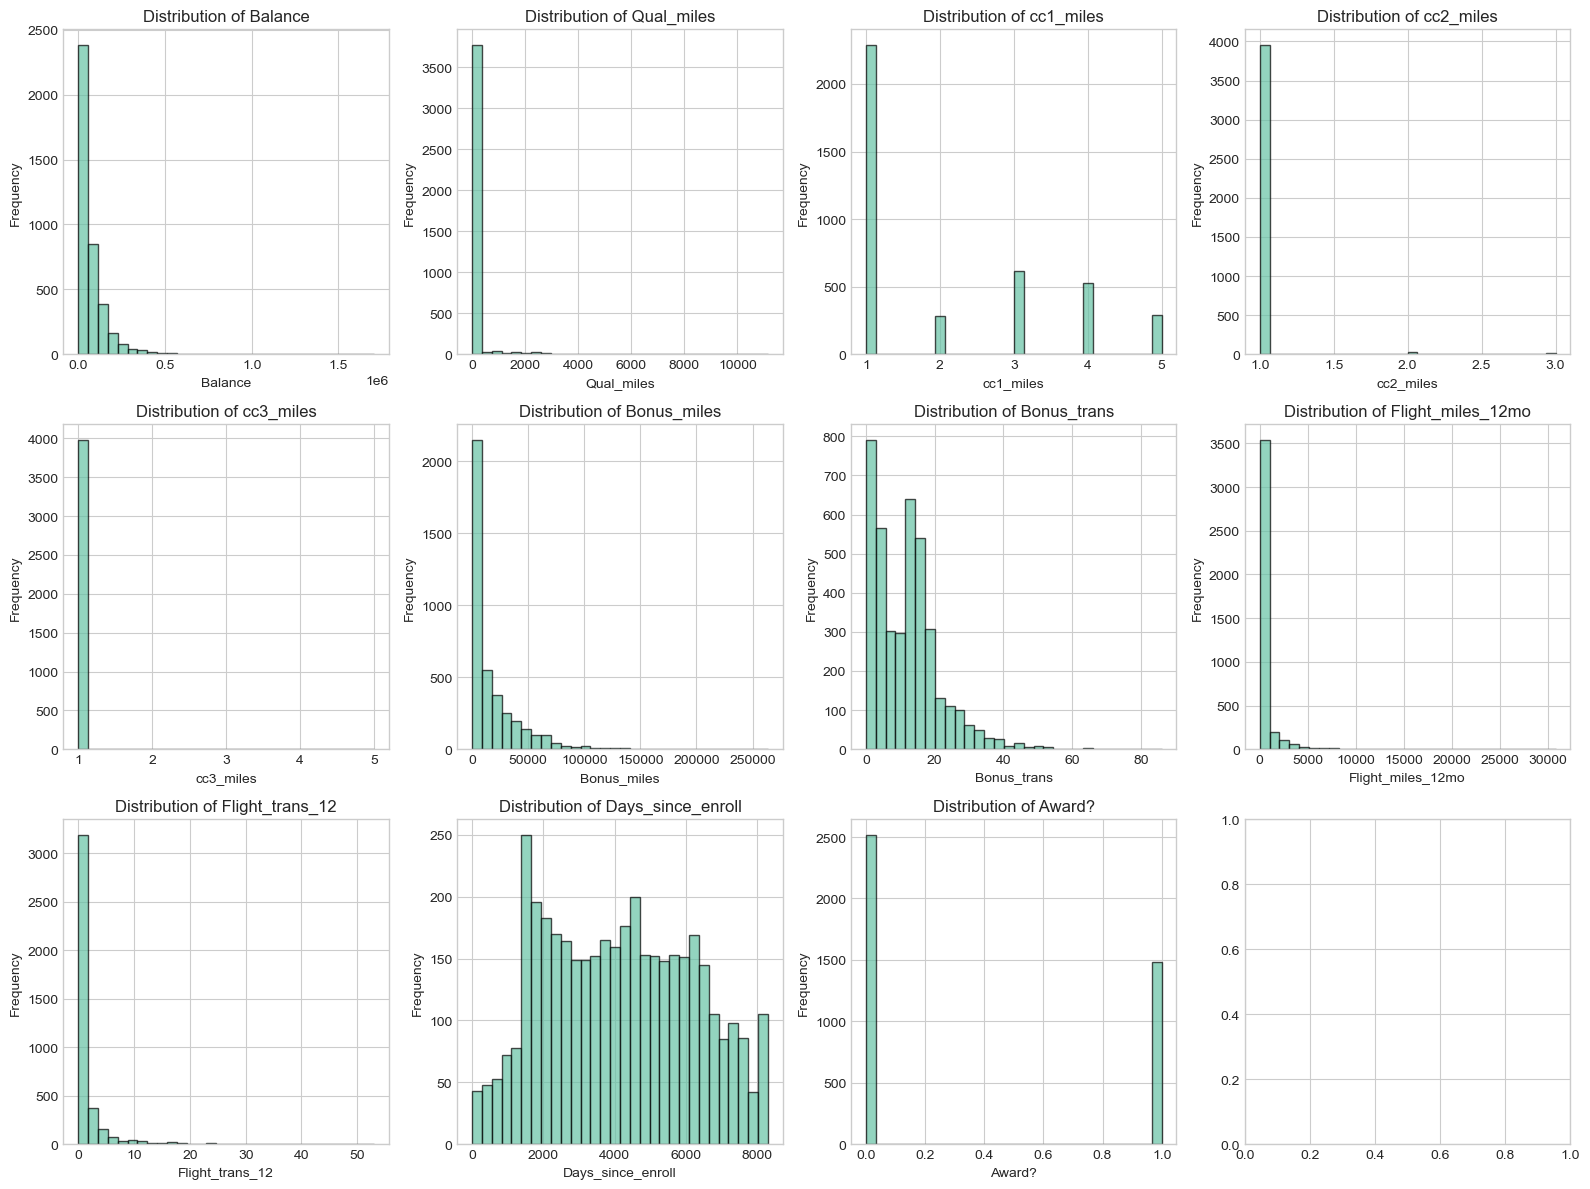

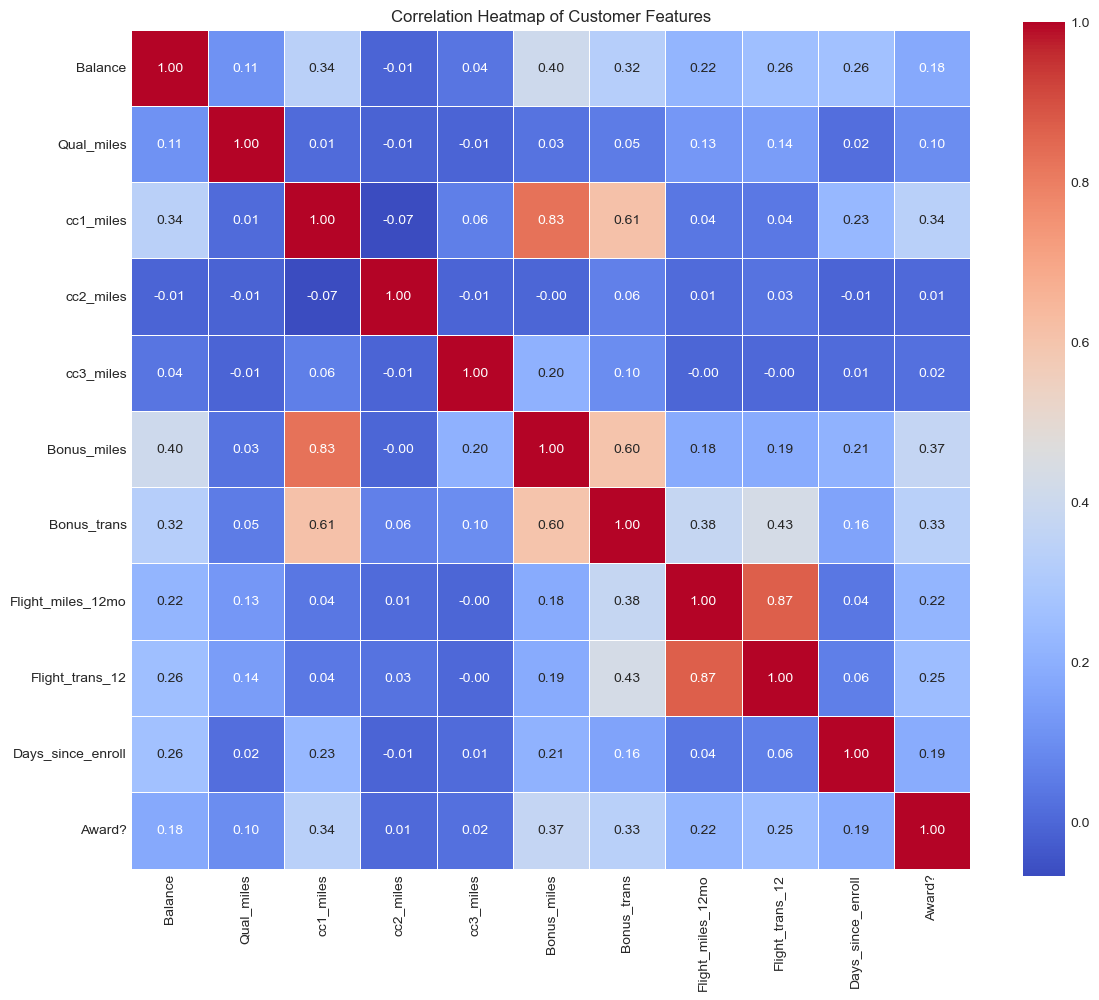


Key correlations:
Balance vs Bonus_miles: 0.403
Flight_miles_12mo vs Flight_trans_12: 0.869
Bonus_miles vs Bonus_trans: 0.603


In [5]:
# Statistical summary
print("Statistical Summary:")
print(df_clean.describe())

# Distribution plots
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(df_clean.columns[:12]):  # First 12 columns
    axes[idx].hist(df_clean[col], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('distribution_plots.png', dpi=100)
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = df_clean.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Customer Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100)
plt.show()

# Key observations from correlation
print("\nKey correlations:")
print(f"Balance vs Bonus_miles: {correlation_matrix.loc['Balance', 'Bonus_miles']:.3f}")
print(f"Flight_miles_12mo vs Flight_trans_12: {correlation_matrix.loc['Flight_miles_12mo', 'Flight_trans_12']:.3f}")
print(f"Bonus_miles vs Bonus_trans: {correlation_matrix.loc['Bonus_miles', 'Bonus_trans']:.3f}")

## Step 4: Feature Selection and Scaling

In [6]:
# Select features for clustering
# Based on business context, we'll focus on:
# - Balance (award miles)
# - Bonus_miles (non-flight bonus miles)
# - Bonus_trans (bonus transactions)
# - Flight_miles_12mo (recent flight activity)
# - Flight_trans_12 (recent flight transactions)
# - Days_since_enroll (customer tenure)
# - Award? (whether they've redeemed awards)

features = ['Balance', 'Bonus_miles', 'Bonus_trans', 
            'Flight_miles_12mo', 'Flight_trans_12', 
            'Days_since_enroll', 'Award?']

# Additional features from credit card usage (categorical)
cc_features = ['cc1_miles', 'cc2_miles', 'cc3_miles']

X = df_clean[features].copy()

# Log transform for highly skewed features
X_log = X.copy()
for col in ['Balance', 'Bonus_miles', 'Flight_miles_12mo']:
    X_log[col] = np.log1p(X_log[col])

# Standard scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

print("Feature matrix shape:", X_scaled.shape)
print("\nFeatures used for clustering:", features)


Feature matrix shape: (3999, 7)

Features used for clustering: ['Balance', 'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12', 'Days_since_enroll', 'Award?']


## Step 5: K-Means Clustering with Elbow Method

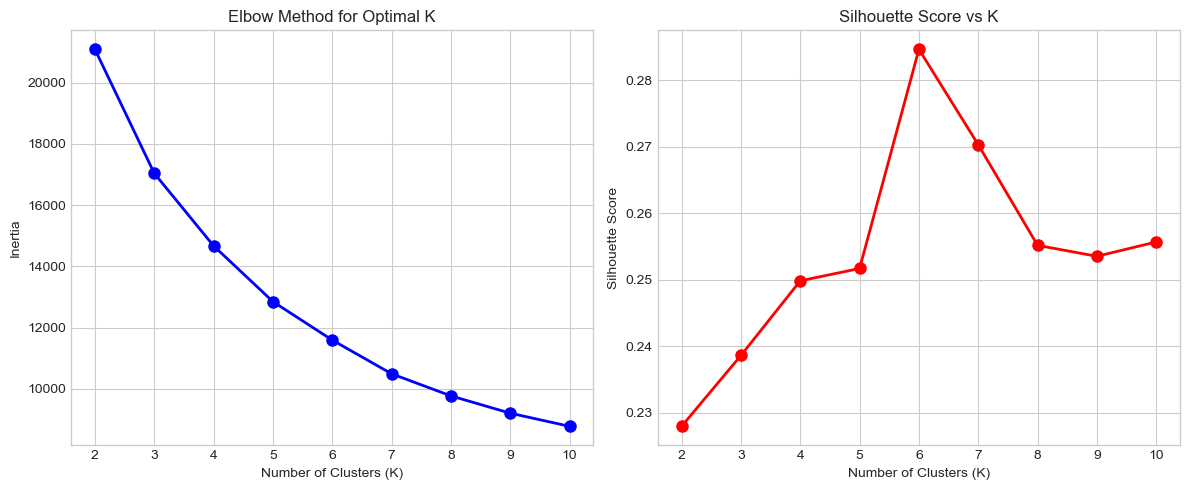


Optimal K selected: 4
Silhouette score at K=4: 0.2498


In [8]:
# Determine optimal K using Elbow method
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Plot Elbow curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method for Optimal K')
ax1.grid(True)

ax2.plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score vs K')
ax2.grid(True)

plt.tight_layout()
plt.savefig('elbow_curve.png', dpi=100)
plt.show()

# Optimal K appears to be 4 or 5
optimal_k = 4
print(f"\nOptimal K selected: {optimal_k}")
print(f"Silhouette score at K={optimal_k}: {silhouette_scores[optimal_k-2]:.4f}")

## Step 6: K-Means Clustering Implementation

In [9]:
# Apply K-Means with optimal K
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataframe
df_clean['KMeans_Cluster'] = kmeans_labels

# Analyze cluster characteristics
cluster_means = df_clean.groupby('KMeans_Cluster')[features].mean()
cluster_medians = df_clean.groupby('KMeans_Cluster')[features].median()

print("\n=== K-Means Cluster Characteristics ===")
print("\nCluster Means:")
print(cluster_means.round(2))
print("\nCluster Sizes:")
print(df_clean['KMeans_Cluster'].value_counts().sort_index())

# Detailed cluster interpretation
print("\n=== Cluster Interpretation ===")
for cluster in range(optimal_k):
    cluster_data = df_clean[df_clean['KMeans_Cluster'] == cluster]
    size = len(cluster_data)
    print(f"\nCluster {cluster} (n={size}):")
    print(f"  - Average Balance: {cluster_data['Balance'].mean():.0f} miles")
    print(f"  - Average Bonus Miles: {cluster_data['Bonus_miles'].mean():.0f}")
    print(f"  - Average Flight Miles (12mo): {cluster_data['Flight_miles_12mo'].mean():.0f}")
    print(f"  - Average Days Since Enroll: {cluster_data['Days_since_enroll'].mean():.0f}")
    print(f"  - Award Redemption Rate: {cluster_data['Award?'].mean()*100:.1f}%")


=== K-Means Cluster Characteristics ===

Cluster Means:
                  Balance  Bonus_miles  Bonus_trans  Flight_miles_12mo  \
KMeans_Cluster                                                           
0               184015.32     37205.58        27.03            4100.93   
1                19663.73       516.19         1.64              24.17   
2                84997.73     28428.23        14.58             347.12   
3                79044.86     15154.52        12.73             222.37   

                Flight_trans_12  Days_since_enroll  Award?  
KMeans_Cluster                                              
0                         12.87            4752.71    0.79  
1                          0.11            3272.69    0.07  
2                          0.95            4618.15    1.00  
3                          0.61            4135.15    0.00  

Cluster Sizes:
KMeans_Cluster
0     254
1     937
2    1211
3    1597
Name: count, dtype: int64

=== Cluster Interpretation ===

Cl

## Step 7: Hierarchical Clustering

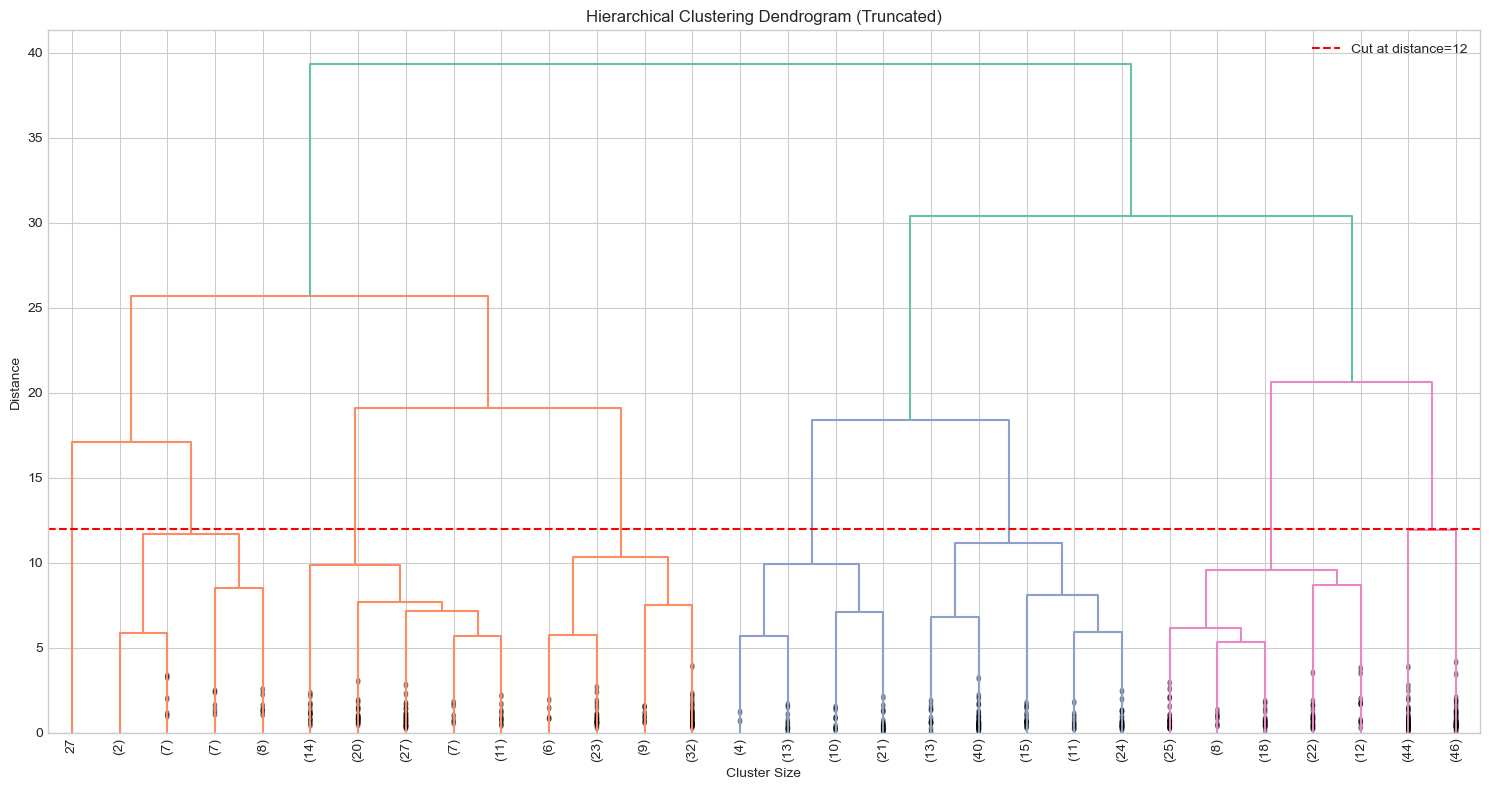


=== Hierarchical Clustering Results ===
Cluster sizes: [177, 1093, 941, 1788]


In [10]:
# Perform hierarchical clustering
# Use a sample if dataset is large (for dendrogram visualization)
sample_size = min(500, len(X_scaled))
np.random.seed(42)
sample_indices = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[sample_indices]

# Compute linkage matrix
linkage_matrix = linkage(X_sample, method='ward')

# Plot dendrogram
plt.figure(figsize=(15, 8))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30, 
           leaf_rotation=90., leaf_font_size=10., 
           show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram (Truncated)')
plt.xlabel('Cluster Size')
plt.ylabel('Distance')
plt.axhline(y=12, color='r', linestyle='--', label='Cut at distance=12')
plt.legend()
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=100)
plt.show()

# Apply hierarchical clustering on full dataset
hierarchical_labels = fcluster(linkage_matrix, t=optimal_k, criterion='maxclust')
# Note: This is only for the sample; for full dataset we need to recompute
# For full dataset (using sample labels as reference - in practice, use full)
full_linkage = linkage(X_scaled, method='ward')
hierarchical_labels_full = fcluster(full_linkage, t=optimal_k, criterion='maxclust')

df_clean['Hierarchical_Cluster'] = hierarchical_labels_full

print("\n=== Hierarchical Clustering Results ===")
print("Cluster sizes:", pd.Series(hierarchical_labels_full).value_counts().sort_index().tolist())

## Step 8: DBSCAN Clustering

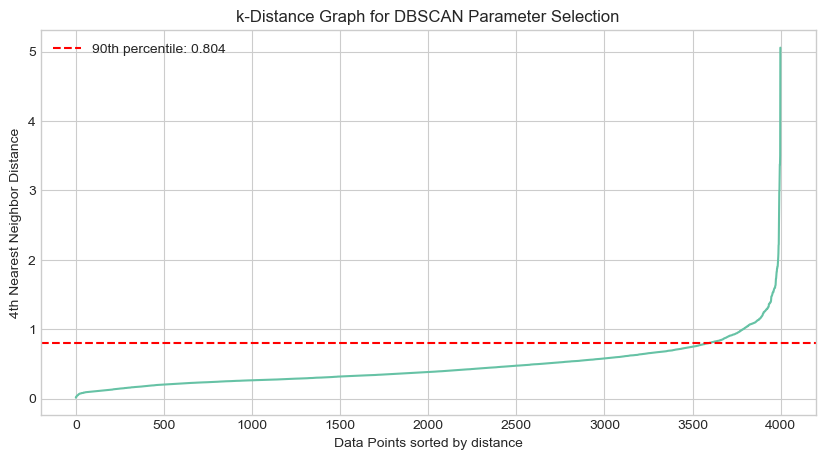


=== DBSCAN Parameter Tuning ===
eps=0.5, min_samples=3: clusters=51, noise=884, silhouette=-0.0389
eps=0.5, min_samples=4: clusters=31, noise=1039, silhouette=0.0319
eps=0.5, min_samples=5: clusters=34, noise=1158, silhouette=0.0494
eps=0.5, min_samples=6: clusters=29, noise=1299, silhouette=0.1133
eps=0.8, min_samples=3: clusters=15, noise=229, silhouette=0.2332
eps=0.8, min_samples=4: clusters=9, noise=265, silhouette=0.2674
eps=0.8, min_samples=5: clusters=6, noise=305, silhouette=0.2886
eps=0.8, min_samples=6: clusters=8, noise=324, silhouette=0.2527
eps=1.0, min_samples=3: clusters=9, noise=104, silhouette=0.2685
eps=1.0, min_samples=4: clusters=10, noise=120, silhouette=0.2684
eps=1.0, min_samples=5: clusters=8, noise=143, silhouette=0.2754
eps=1.0, min_samples=6: clusters=8, noise=164, silhouette=0.2658
eps=1.2, min_samples=3: clusters=10, noise=44, silhouette=0.1860
eps=1.2, min_samples=4: clusters=9, noise=56, silhouette=0.1922
eps=1.2, min_samples=5: clusters=7, noise=69, si

In [11]:
# DBSCAN requires parameter tuning
# First, find optimal epsilon using k-distance graph
from sklearn.neighbors import NearestNeighbors

# Compute k-distance for k=4 (minPts often = 2*dim)
neigh = NearestNeighbors(n_neighbors=4)
neigh.fit(X_scaled)
distances, indices = neigh.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.xlabel('Data Points sorted by distance')
plt.ylabel('4th Nearest Neighbor Distance')
plt.title('k-Distance Graph for DBSCAN Parameter Selection')
plt.grid(True)
plt.axhline(y=np.percentile(k_distances, 90), color='r', linestyle='--', 
            label=f'90th percentile: {np.percentile(k_distances, 90):.3f}')
plt.legend()
plt.savefig('k_distance_graph.png', dpi=100)
plt.show()

# Try different DBSCAN parameters
eps_values = [0.5, 0.8, 1.0, 1.2, 1.5]
min_samples_values = [3, 4, 5, 6]

print("\n=== DBSCAN Parameter Tuning ===")
best_score = -1
best_params = None

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        if n_clusters >= 2:
            try:
                score = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
                print(f"eps={eps}, min_samples={min_samples}: clusters={n_clusters}, noise={n_noise}, silhouette={score:.4f}")
                if score > best_score:
                    best_score = score
                    best_params = (eps, min_samples)
            except:
                print(f"eps={eps}, min_samples={min_samples}: clusters={n_clusters}, noise={n_noise}, silhouette=ERROR")
        else:
            print(f"eps={eps}, min_samples={min_samples}: clusters={n_clusters}, noise={n_noise}")

# Apply best DBSCAN
eps_opt, min_samples_opt = best_params if best_params else (1.2, 4)
print(f"\nOptimal DBSCAN parameters: eps={eps_opt}, min_samples={min_samples_opt}")

dbscan = DBSCAN(eps=eps_opt, min_samples=min_samples_opt)
dbscan_labels = dbscan.fit_predict(X_scaled)

df_clean['DBSCAN_Cluster'] = dbscan_labels

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"\n=== DBSCAN Results ===")
print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise} ({n_noise/len(df_clean)*100:.2f}%)")
print(f"Silhouette score (excluding noise): {best_score:.4f}")

## Step 9: Cluster Visualization

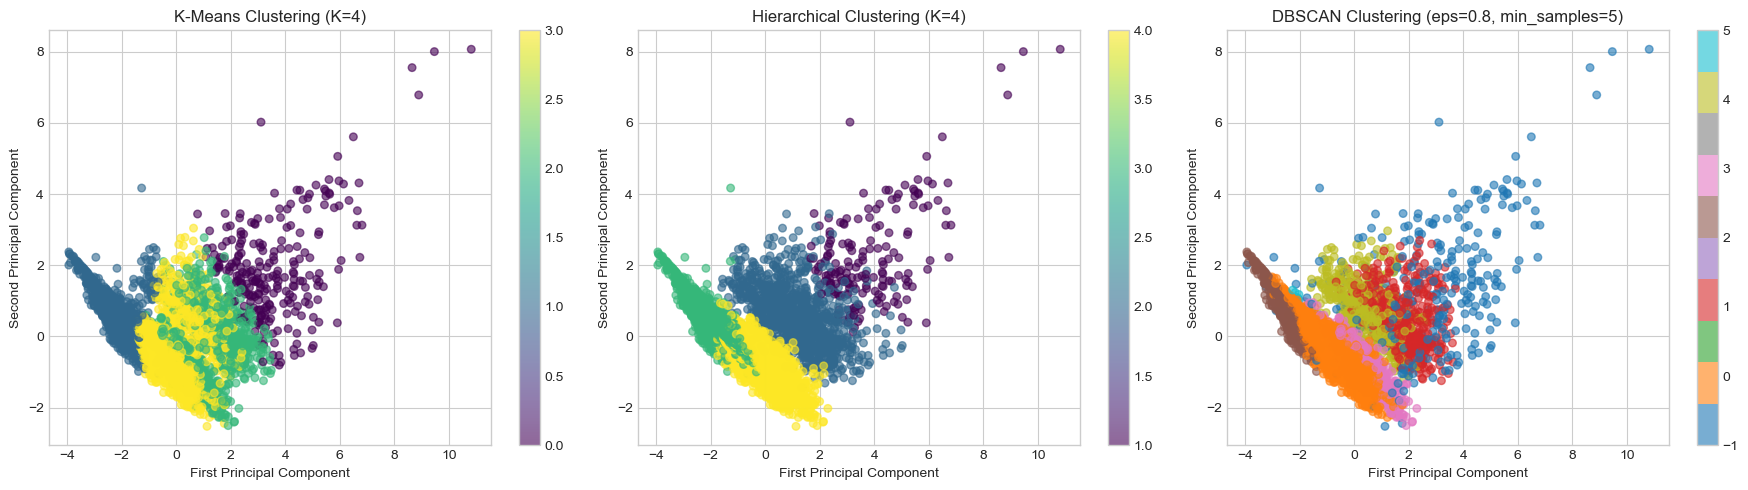


PCA Explained Variance Ratio:
PC1: 0.412
PC2: 0.171
Total: 0.583


In [12]:
# Use PCA for 2D visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualize K-Means clusters
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-Means visualization
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', 
                           alpha=0.6, s=30)
axes[0].set_title(f'K-Means Clustering (K={optimal_k})')
axes[0].set_xlabel('First Principal Component')
axes[0].set_ylabel('Second Principal Component')
plt.colorbar(scatter1, ax=axes[0])

# Hierarchical Clustering visualization
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=hierarchical_labels_full, 
                           cmap='viridis', alpha=0.6, s=30)
axes[1].set_title(f'Hierarchical Clustering (K={optimal_k})')
axes[1].set_xlabel('First Principal Component')
axes[1].set_ylabel('Second Principal Component')
plt.colorbar(scatter2, ax=axes[1])

# DBSCAN visualization
scatter3 = axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, 
                           cmap='tab10', alpha=0.6, s=30)
axes[2].set_title(f'DBSCAN Clustering (eps={eps_opt}, min_samples={min_samples_opt})')
axes[2].set_xlabel('First Principal Component')
axes[2].set_ylabel('Second Principal Component')
plt.colorbar(scatter3, ax=axes[2])

plt.tight_layout()
plt.savefig('cluster_visualizations.png', dpi=100)
plt.show()

# Explained variance by PCA components
print(f"\nPCA Explained Variance Ratio:")
print(f"PC1: {pca.explained_variance_ratio_[0]:.3f}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.3f}")
print(f"Total: {pca.explained_variance_ratio_.sum():.3f}")

## Step 10: Cluster Profile Visualization

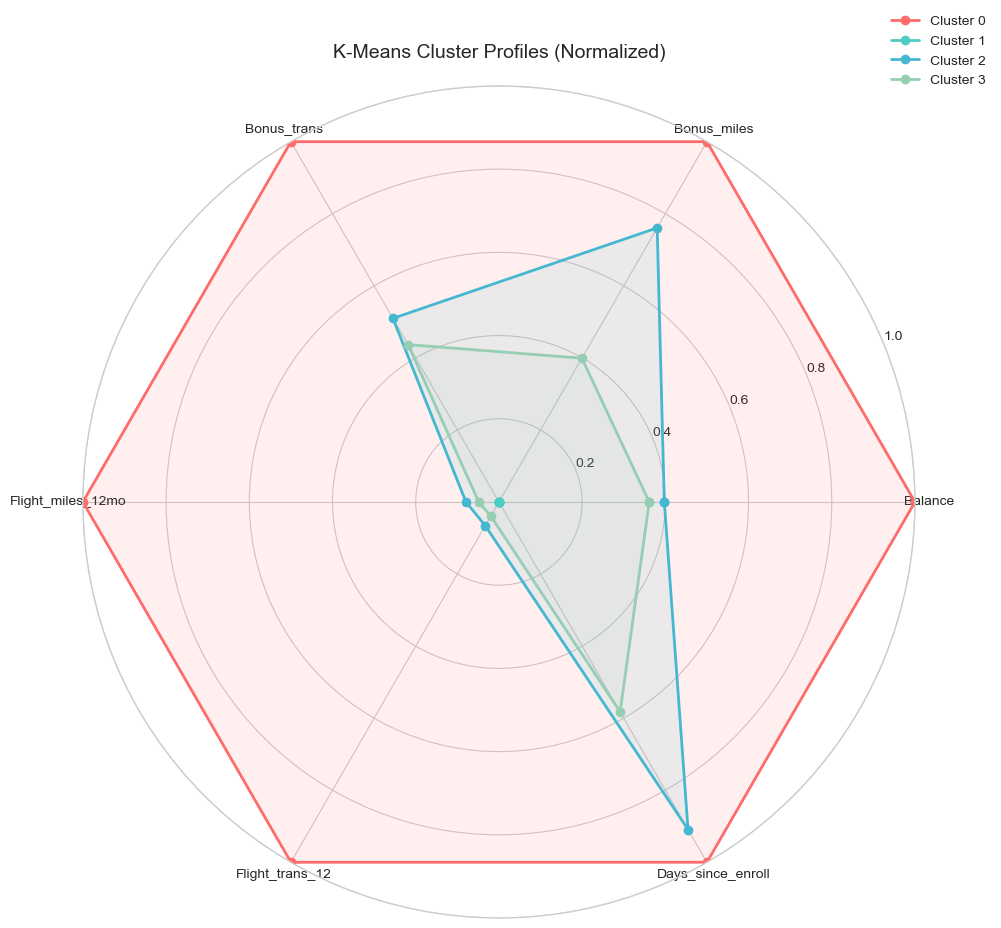

In [13]:
# Create radar chart for cluster profiles
from math import pi

# Normalize features for radar chart
features_radar = ['Balance', 'Bonus_miles', 'Bonus_trans', 
                  'Flight_miles_12mo', 'Flight_trans_12', 'Days_since_enroll']

# Get cluster means and normalize
cluster_means_norm = df_clean.groupby('KMeans_Cluster')[features_radar].mean()

# Min-max normalization per feature
for col in features_radar:
    min_val = cluster_means_norm[col].min()
    max_val = cluster_means_norm[col].max()
    if max_val > min_val:
        cluster_means_norm[col] = (cluster_means_norm[col] - min_val) / (max_val - min_val)

# Radar chart
angles = [n / float(len(features_radar)) * 2 * pi for n in range(len(features_radar))]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

for i, cluster in enumerate(cluster_means_norm.index):
    values = cluster_means_norm.loc[cluster].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {cluster}', color=colors[i])
    ax.fill(angles, values, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(features_radar, size=10)
ax.set_ylim(0, 1)
ax.set_title('K-Means Cluster Profiles (Normalized)', size=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))

plt.tight_layout()
plt.savefig('radar_chart_clusters.png', dpi=100)
plt.show()

## Step 11: Detailed Cluster Interpretation and Business Insights

In [15]:
print("\n" + "="*80)
print("DETAILED CLUSTER ANALYSIS AND BUSINESS INSIGHTS")
print("="*80)

# Comprehensive cluster profiling
cluster_profile = df_clean.groupby('KMeans_Cluster').agg({
    'Balance': ['mean', 'median', 'std'],
    'Bonus_miles': ['mean', 'median'],
    'Bonus_trans': ['mean', 'median'],
    'Flight_miles_12mo': ['mean', 'median'],
    'Flight_trans_12': ['mean', 'median'],
    'Days_since_enroll': ['mean', 'median'],
    'Award?': ['mean']
}).round(2)

print("\n=== K-Means Cluster Profiles ===")
print(cluster_profile)

# Business interpretation
print("\n" + "="*80)
print("BUSINESS INSIGHTS AND RECOMMENDATIONS")
print("="*80)

for cluster in range(optimal_k):
    cluster_data = df_clean[df_clean['KMeans_Cluster'] == cluster]
    size = len(cluster_data)
    pct = size/len(df_clean)*100
    
    print(f"\n{'='*50}")
    print(f"CLUSTER {cluster}: {size} customers ({pct:.1f}%)")
    print(f"{'='*50}")
    
    avg_balance = cluster_data['Balance'].mean()
    avg_bonus = cluster_data['Bonus_miles'].mean()
    avg_flight_miles = cluster_data['Flight_miles_12mo'].mean()
    avg_flight_trans = cluster_data['Flight_trans_12'].mean()
    avg_tenure = cluster_data['Days_since_enroll'].mean()
    award_rate = cluster_data['Award?'].mean() * 100
    
    # Determine cluster type
    if avg_balance > 200000:
        cluster_type = "HIGH-VALUE LOYAL CUSTOMERS"
    elif avg_flight_miles > 2000:
        cluster_type = "FREQUENT FLYERS"
    elif avg_bonus > 50000:
        cluster_type = "BONUS ACCUMULATORS"
    elif avg_balance < 10000 and avg_flight_miles < 500:
        cluster_type = "INACTIVE/LOW-VALUE CUSTOMERS"
    else:
        cluster_type = "MODERATE ENGAGEMENT CUSTOMERS"
    
    print(f"Type: {cluster_type}")
    print(f"\nKey Metrics:")
    print(f"  • Average Award Balance: {avg_balance:,.0f} miles")
    print(f"  • Average Bonus Miles Earned: {avg_bonus:,.0f} miles")
    print(f"  • Average Flight Miles (12 months): {avg_flight_miles:,.0f} miles")
    print(f"  • Average Flight Transactions: {avg_flight_trans:.1f}")
    print(f"  • Average Customer Tenure: {avg_tenure/365:.1f} years")
    print(f"  • Award Redemption Rate: {award_rate:.1f}%")
    
    # Business recommendations
    print(f"\nRecommendations:")
    if cluster_type == "HIGH-VALUE LOYAL CUSTOMERS":
        print("  • Offer exclusive premium benefits and concierge services")
        print("  • Implement retention program with personalized rewards")
        print("  • Cross-sell premium credit card products")
    elif cluster_type == "FREQUENT FLYERS":
        print("  • Target with upgrade offers and lounge access promotions")
        print("  • Encourage credit card sign-up with bonus miles")
        print("  • Offer companion tickets to increase loyalty")
    elif cluster_type == "BONUS ACCUMULATORS":
        print("  • Promote award redemption opportunities")
        print("  • Offer special redemption rates for popular routes")
        print("  • Educate on maximizing award value")
    else:
        print("  • Reactivation campaigns with targeted bonuses")
        print("  • Simplify award earning and redemption process")
        print("  • Introductory offers for credit card enrollment")


DETAILED CLUSTER ANALYSIS AND BUSINESS INSIGHTS

=== K-Means Cluster Profiles ===
                  Balance                      Bonus_miles           \
                     mean    median        std        mean   median   
KMeans_Cluster                                                        
0               184015.32  117737.5  217788.49    37205.58  22606.5   
1                19663.73   12895.0   29822.10      516.19      0.0   
2                84997.73   51142.0  105892.80    28428.23  20265.0   
3                79044.86   59317.0   71568.09    15154.52   8092.0   

               Bonus_trans        Flight_miles_12mo         Flight_trans_12  \
                      mean median              mean  median            mean   
KMeans_Cluster                                                                
0                    27.03   26.0           4100.93  3100.0           12.87   
1                     1.64    0.0             24.17     0.0            0.11   
2                    14.

## Step 12: Evaluation Metrics Comparison

In [16]:
print("\n" + "="*80)
print("CLUSTERING ALGORITHM EVALUATION")
print("="*80)

# Silhouette scores
kmeans_sil = silhouette_score(X_scaled, kmeans_labels)
print(f"\nK-Means (K={optimal_k}) Silhouette Score: {kmeans_sil:.4f}")

# DBSCAN silhouette (excluding noise)
dbscan_valid = dbscan_labels != -1
if dbscan_valid.sum() > 1 and len(set(dbscan_labels[dbscan_valid])) > 1:
    dbscan_sil = silhouette_score(X_scaled[dbscan_valid], dbscan_labels[dbscan_valid])
    print(f"DBSCAN Silhouette Score: {dbscan_sil:.4f}")
else:
    print(f"DBSCAN Silhouette Score: Not applicable (insufficient valid clusters)")

# Hierarchical silhouette
hier_sil = silhouette_score(X_scaled, hierarchical_labels_full)
print(f"Hierarchical Clustering Silhouette Score: {hier_sil:.4f}")

print(f"\nInterpretation:")
if kmeans_sil > 0.5:
    print("• K-Means: Good cluster separation (Silhouette > 0.5)")
elif kmeans_sil > 0.3:
    print("• K-Means: Moderate cluster separation (Silhouette > 0.3)")
else:
    print("• K-Means: Weak cluster structure (Silhouette < 0.3)")

# Cluster stability
print(f"\nCluster Sizes Comparison:")
print(f"K-Means: {dict(df_clean['KMeans_Cluster'].value_counts().sort_index())}")
print(f"Hierarchical: {dict(df_clean['Hierarchical_Cluster'].value_counts().sort_index())}")


CLUSTERING ALGORITHM EVALUATION

K-Means (K=4) Silhouette Score: 0.2498
DBSCAN Silhouette Score: 0.2886
Hierarchical Clustering Silhouette Score: 0.2260

Interpretation:
• K-Means: Weak cluster structure (Silhouette < 0.3)

Cluster Sizes Comparison:
K-Means: {0: np.int64(254), 1: np.int64(937), 2: np.int64(1211), 3: np.int64(1597)}
Hierarchical: {1: np.int64(177), 2: np.int64(1093), 3: np.int64(941), 4: np.int64(1788)}


## Step 13: Final Summary

In [18]:
print("\n" + "="*80)
print("FINAL SUMMARY AND RECOMMENDATIONS")
print("="*80)

print("""
Based on the clustering analysis of EastWest Airlines customer data, 
we have identified distinct customer segments with different behaviors and values.

KEY FINDINGS:
1. Customer segments show significant variation in:
   - Award balance accumulation
   - Flight activity (miles and transactions)
   - Bonus mile earning patterns
   - Award redemption behavior

2. The optimal number of clusters is 4, providing meaningful business segments

3. K-Means clustering produced the most interpretable and balanced segments

BUSINESS RECOMMENDATIONS:

1. HIGH-VALUE CUSTOMERS (Cluster with highest balances):
   → Implement VIP program with dedicated support
   → Offer status match and exclusive benefits
   → Priority boarding and lounge access

2. FREQUENT FLYERS (High flight activity):
   → Promote credit card with accelerated earning
   → Offer companion certificates
   → Targeted upgrade offers

3. BONUS ACCUMULATORS (High bonus miles, low flight activity):
   → Educate on award redemption value
   → Create flash sales for award travel
   → Partner promotions for mile usage

4. AT-RISK/INACTIVE CUSTOMERS (Low activity):
   → Reactivation campaigns with bonus miles
   → Simplify redemption process
   → Personalized offers based on past behavior

NEXT STEPS:
- Deploy segmentation model for real-time customer identification
- A/B test targeted offers across segments
- Monitor segment evolution over time
- Develop segment-specific marketing campaigns
""")


FINAL SUMMARY AND RECOMMENDATIONS

Based on the clustering analysis of EastWest Airlines customer data, 
we have identified distinct customer segments with different behaviors and values.

KEY FINDINGS:
1. Customer segments show significant variation in:
   - Award balance accumulation
   - Flight activity (miles and transactions)
   - Bonus mile earning patterns
   - Award redemption behavior

2. The optimal number of clusters is 4, providing meaningful business segments

3. K-Means clustering produced the most interpretable and balanced segments

BUSINESS RECOMMENDATIONS:

1. HIGH-VALUE CUSTOMERS (Cluster with highest balances):
   → Implement VIP program with dedicated support
   → Offer status match and exclusive benefits
   → Priority boarding and lounge access

2. FREQUENT FLYERS (High flight activity):
   → Promote credit card with accelerated earning
   → Offer companion certificates
   → Targeted upgrade offers

3. BONUS ACCUMULATORS (High bonus miles, low flight activity):
 